<a href="https://colab.research.google.com/github/Enigmatic-SGaur/Q-Skill-Internship-/blob/main/Q_Skill_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- DATASET OVERVIEW ---
   Store_ID Region  Advertising_Budget_k$  Foot_Traffic  Monthly_Sales_k$
0       101  North                     12          1500               150
1       102  South                     25          2300               230
2       103   East                     18          1800               190
3       104   West                     30          2900               310
4       105  North                     15          1600               165

--- SUMMARY STATISTICS ---
        Store_ID  Advertising_Budget_k$  Foot_Traffic  Monthly_Sales_k$
count   10.00000               10.00000      10.00000         10.000000
mean   105.50000               21.50000    2130.00000        221.500000
std      3.02765                8.08634     646.44326         70.634033
min    101.00000               10.00000    1200.00000        125.000000
25%    103.25000               15.75000    1650.00000        171.250000
50%    105.50000               21.00000    2050.00000        210.000000

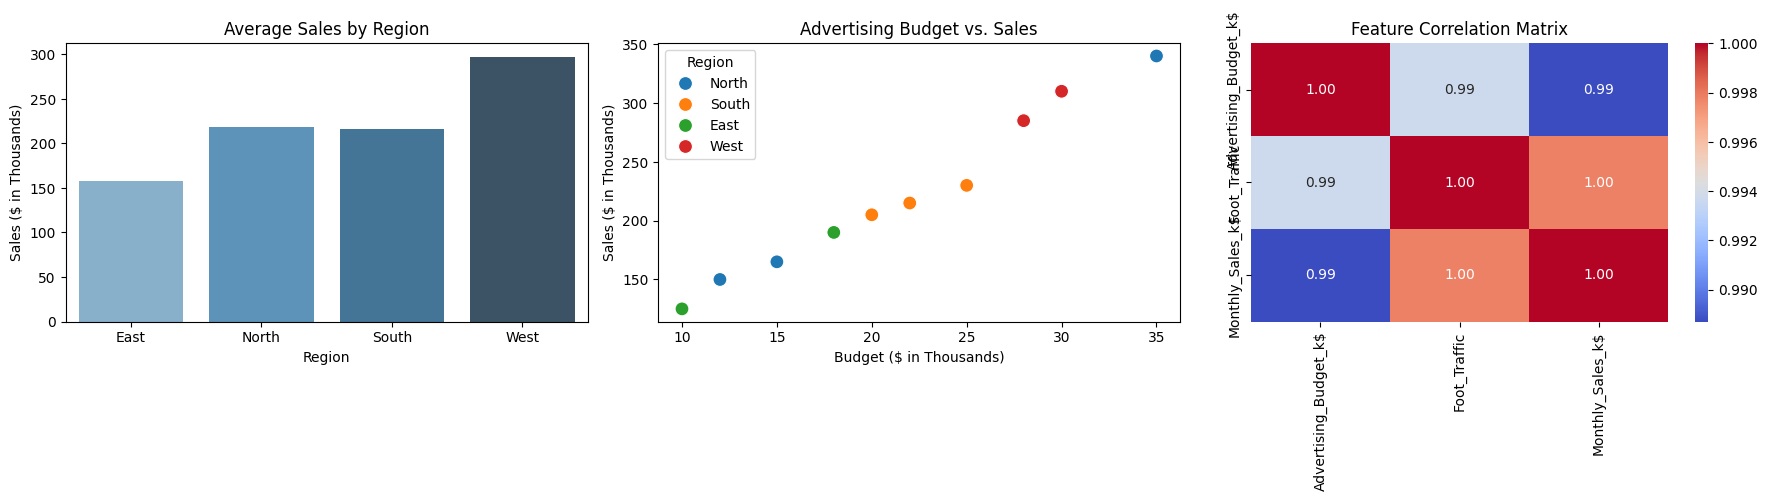

In [7]:
# ==========================================
# TASK 1: Basic Data Analysis & Visualization
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Create a synthetic dataset (Replace 'data.csv' with your local CSV if preferred)
data = {
    'Store_ID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Region': ['North', 'South', 'East', 'West', 'North', 'South', 'East', 'West', 'North', 'South'],
    'Advertising_Budget_k$': [12, 25, 18, 30, 15, 22, 10, 28, 35, 20],
    'Foot_Traffic': [1500, 2300, 1800, 2900, 1600, 2100, 1200, 2700, 3200, 2000],
    'Monthly_Sales_k$': [150, 230, 190, 310, 165, 215, 125, 285, 340, 205]
}

df = pd.DataFrame(data)

# 2. Data Analysis
print("--- DATASET OVERVIEW ---")
print(df.head())
print("\n--- SUMMARY STATISTICS ---")
print(df.describe())

# Calculate specific averages
avg_sales = df['Monthly_Sales_k$'].mean()
avg_budget = df['Advertising_Budget_k$'].mean()

print(f"\nAverage Monthly Sales: ${avg_sales:.2f}k")
print(f"Average Advertising Budget: ${avg_budget:.2f}k")

# Insights Printout
print("\n--- INSIGHTS & OBSERVATIONS ---")
print("1. Region Trend: Stores with higher advertising budgets consistently report higher foot traffic and monthly sales.")
print("2. Average Performance: Average store sales sit at ~$222k per month with an average budget of ~$21.5k.")

# 3. Data Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Bar Chart (Sales by Region)
region_sales = df.groupby('Region')['Monthly_Sales_k$'].mean().reset_index()
sns.barplot(data=region_sales, x='Region', y='Monthly_Sales_k$', ax=axes[0], palette='Blues_d')
axes[0].set_title('Average Sales by Region')
axes[0].set_ylabel('Sales ($ in Thousands)')

# Plot 2: Scatter Plot (Budget vs. Sales)
sns.scatterplot(data=df, x='Advertising_Budget_k$', y='Monthly_Sales_k$', hue='Region', s=100, ax=axes[1])
axes[1].set_title('Advertising Budget vs. Sales')
axes[1].set_xlabel('Budget ($ in Thousands)')
axes[1].set_ylabel('Sales ($ in Thousands)')

# Plot 3: Heatmap (Correlation Matrix)
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['Store_ID'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', ax=axes[2], fmt='.2f')
axes[2].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()

Dataset successfully loaded with shape: (2930, 82)

--- FIRST 5 ROWS ---
   Gr Liv Area  Bedroom AbvGr Neighborhood  Year Built  SalePrice
0         1656              3        NAmes        1960     215000
1          896              2        NAmes        1961     105000
2         1329              3        NAmes        1958     172000
3         2110              3        NAmes        1968     244000
4         1629              3      Gilbert        1997     189900

--- MODEL PERFORMANCE METRICS ---
Mean Absolute Error (MAE)  : $24,175.57
Root Mean Squared Error (RMSE): $38,877.99
R² Score                   : 0.8115


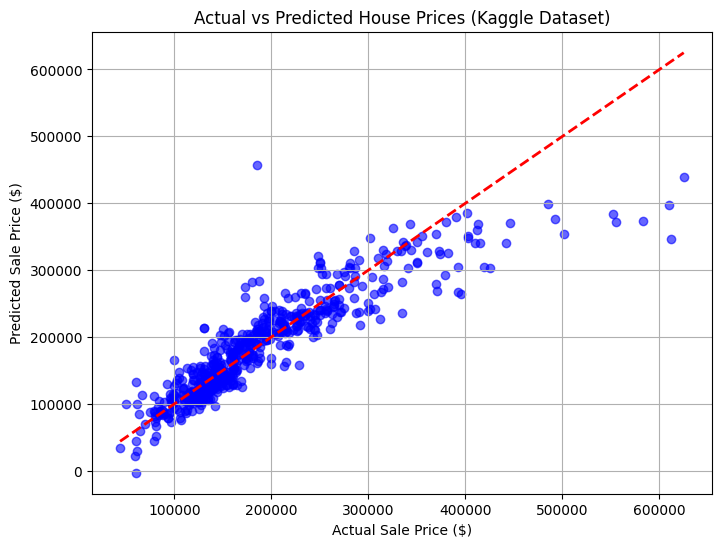

In [8]:
# ==============================================================================
# TASK 2: Linear Regression for House Price Prediction (Kaggle Dataset)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# 1. FETCH DATASET FROM KAGGLE REPOSITORY
# We load the Ames, Iowa House Prices dataset directly via raw GitHub repository host
dataset_url = "/content/archive (26).zip"
print("Downloading Kaggle House Prices dataset...")
df = pd.read_csv("/content/archive (26).zip")
print(f"Dataset successfully loaded with shape: {df.shape}\n")

# Display initial data summary
print("--- FIRST 5 ROWS ---")
print(df[['Gr Liv Area', 'Bedroom AbvGr', 'Neighborhood', 'Year Built', 'SalePrice']].head())

# 2. DATA PREPROCESSING & FEATURE SELECTION
# Select key predictive features:
# - Size (Square Footage): 'Gr Liv Area'
# - Rooms/Bedrooms: 'Bedrooms' (or 'TotRms AbvGrd')
# - Location: 'Neighborhood'
# - Age/Year: 'Year Built'
# - Overall Quality: 'Overall Qual'
selected_features = ['Gr Liv Area', 'TotRms AbvGrd', 'Neighborhood', 'Year Built', 'Overall Qual']
target = 'SalePrice'

# Filter dataset to selected features and target variable
df_model = df[selected_features + [target]].copy()

# Handle Missing Values (Imputation)
# NEW (Clean & Future-Proof)
df_model['Gr Liv Area'] = df_model['Gr Liv Area'].fillna(df_model['Gr Liv Area'].median())
df_model['TotRms AbvGrd'] = df_model['TotRms AbvGrd'].fillna(df_model['TotRms AbvGrd'].median())
df_model['Year Built'] = df_model['Year Built'].fillna(df_model['Year Built'].median())
df_model['Overall Qual'] = df_model['Overall Qual'].fillna(df_model['Overall Qual'].median())

# One-Hot Encoding for categorical feature 'Neighborhood' (Location)
df_processed = pd.get_dummies(df_model, columns=['Neighborhood'], drop_first=True)

# Separate features (X) and target variable (y)
X = df_processed.drop(columns=[target])
y = df_processed[target]

# 3. SPLIT DATASET (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. FEATURE SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. TRAIN LINEAR REGRESSION MODEL
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 6. MODEL EVALUATION
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- MODEL PERFORMANCE METRICS ---")
print(f"Mean Absolute Error (MAE)  : ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R² Score                   : {r2:.4f}")

# 7. VISUALIZE PREDICTIONS VS ACTUAL PRICES
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Actual vs Predicted House Prices (Kaggle Dataset)")
plt.xlabel("Actual Sale Price ($)")
plt.ylabel("Predicted Sale Price ($)")
plt.grid(True)
plt.show()

In [9]:
# ==========================================
# TASK 3: Interactive Matrix Operations Tool
# ==========================================

import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create Widget Elements
operation_dropdown = widgets.Dropdown(
    options=['Addition (A + B)', 'Subtraction (A - B)', 'Multiplication (A x B)', 'Transpose (A)', 'Determinant (det(A))'],
    value='Addition (A + B)',
    description='Operation:',
    style={'description_width': 'initial'}
)

# Text areas for entering matrices as string representation
matrix_a_input = widgets.Textarea(
    value='1, 2\n3, 4',
    description='Matrix A:',
    placeholder='Enter rows separated by newlines, values separated by commas'
)

matrix_b_input = widgets.Textarea(
    value='5, 6\n7, 8',
    description='Matrix B:',
    placeholder='Enter rows separated by newlines, values separated by commas'
)

button = widgets.Button(description="Calculate", button_style='primary')
output = widgets.Output()

def parse_matrix(text):
    """Helper function to parse multiline string input into a NumPy array."""
    lines = text.strip().split('\n')
    return np.array([[float(x.strip()) for x in line.split(',')] for line in lines if line.strip()])

def on_button_clicked(b):
    with output:
        clear_output()
        try:
            mat_a = parse_matrix(matrix_a_input.value)
            op = operation_dropdown.value

            print("--- INPUT MATRIX A ---")
            print(mat_a)

            if op in ['Addition (A + B)', 'Subtraction (A - B)', 'Multiplication (A x B)']:
                mat_b = parse_matrix(matrix_b_input.value)
                print("\n--- INPUT MATRIX B ---")
                print(mat_b)
                print("\n--- RESULT ---")

                if op == 'Addition (A + B)':
                    print(np.add(mat_a, mat_b))
                elif op == 'Subtraction (A - B)':
                    print(np.subtract(mat_a, mat_b))
                elif op == 'Multiplication (A x B)':
                    print(np.matmul(mat_a, mat_b))

            elif op == 'Transpose (A)':
                print("\n--- RESULT (TRANSPOSE) ---")
                print(np.transpose(mat_a))

            elif op == 'Determinant (det(A))':
                print("\n--- RESULT (DETERMINANT) ---")
                if mat_a.shape[0] != mat_a.shape[1]:
                    print("Error: Determinant requires a square matrix!")
                else:
                    det = np.linalg.det(mat_a)
                    print(f"det(A) = {det:.4f}")

        except Exception as e:
            print(f"Error processing calculation: {str(e)}")

button.on_click(on_button_clicked)

# Display Interactive App Interface
print("=== NumPy Matrix Operations Tool ===")
display(operation_dropdown, matrix_a_input, matrix_b_input, button, output)

=== NumPy Matrix Operations Tool ===


Dropdown(description='Operation:', options=('Addition (A + B)', 'Subtraction (A - B)', 'Multiplication (A x B)…

Textarea(value='1, 2\n3, 4', description='Matrix A:', placeholder='Enter rows separated by newlines, values se…

Textarea(value='5, 6\n7, 8', description='Matrix B:', placeholder='Enter rows separated by newlines, values se…

Button(button_style='primary', description='Calculate', style=ButtonStyle())

Output()